### TO DO

- Create parts of speech tags

- plot the most frequent unigram (token) for each timeline

- show the most freq unigrams POS

- show the most freq unigrams NER

- Plot bigrams and trigrams for each timeline

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
import random
import time
from tqdm.notebook import tqdm
import arabic_reshaper
from bidi.algorithm import get_display

# Shekar
from shekar import POSTagger, NER, WordTokenizer

# NLTK
from nltk import ngrams
import nltk
nltk.download('punkt_tab', quiet = True)

print('Done.')

Done.


[nltk_data] Error loading punkt_tab: <urlopen error [Errno 111]
[nltk_data]     Connection refused>


In [38]:
# Plot settings
sns.set_theme(style = 'whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

In [39]:
# Load the data
df = pd.read_csv('../data/preprocessed/all_processed.csv', encoding = 'utf-8-sig')

In [40]:
# Convert string lists to actual lists
for col in ['tokens', 'tokens_persian', 'tokens_stemmed', 'final_tokens_sent', 'final_tokens_freq']:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11174 entries, 0 to 11173
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   message_id         11174 non-null  int64 
 1   cleaned_text       11174 non-null  str   
 2   timeline           11174 non-null  str   
 3   normalized         11174 non-null  str   
 4   tokens             11174 non-null  object
 5   tokens_persian     11174 non-null  object
 6   tokens_stemmed     11174 non-null  object
 7   final_tokens_sent  11174 non-null  object
 8   final_tokens_freq  11174 non-null  object
dtypes: int64(1), object(5), str(3)
memory usage: 5.9+ MB


In [41]:
df.head(2)

,message_id,cleaned_text,timeline,normalized,tokens,tokens_persian,tokens_stemmed,final_tokens_sent,final_tokens_freq
0,129507,تنها کسی که تو مملکت داره کارش رو خوب انجام می...,timeline_1,تنها کسی که تو مملکت داره کارش رو خوب انجام می...,"[تنها, کسی, که, تو, مملکت, داره, کارش, رو, خوب...","[تنها, کسی, که, تو, مملکت, داره, کارش, رو, خوب...","[تنها, کسی, که, تو, مملک, داره, کار, را, خوب, ...","[کسی, مملک, خوب, انجا, چسب, زن, الویه, نامینو,...","[مملک, انجا, چسب, زن, الویه, نامینو, دادا, یکم..."
1,129512,اولین سالی که بابانوئل برای بچه‌های ما چیزی آو...,timeline_1,اولین سالی که بابانوئل برای بچه‌های ما چیزی آو...,"[اولین, سالی, که, بابانوئل, برای, بچه‌های, ما,...","[اولین, سالی, که, بابانوئل, برای, بچه‌های, ما,...","[اولین, سال, که, بابانوئل, برا, بچه, ما, چیز, ...","[اولین, بابانوئل, آورد, فکر, واکن, دختر, صبح, ...","[بابانوئل, آورد, فکر, واکن, دختر, صبح, بیدار, ..."


In [42]:
# Top 50 words per timeline
TOP_N_WORDS = 50
TOP_WORDS_PRE_TL = {}
all_top_words = set()

for tl in sorted(df['timeline'].unique()):
    tdf = df[df['timeline'] == tl]

    all_tokens = [tok for tokens in tdf['final_tokens_freq'] for tok in tokens]
    cnt = Counter(all_tokens)
    top = cnt.most_common(TOP_N_WORDS)
    top_words = [word for word, _ in top]
    TOP_WORDS_PRE_TL[tl] = top_words
    all_top_words.update(top_words)
    
    print(f'{tl}: top 10 words: {top_words[:10]}')

timeline_1: top 10 words: ['زندگی', 'بابا', 'مامان', 'خانه', 'دختر', 'پسر', 'فکر', 'درس', 'مرد', 'آدم']
timeline_2: top 10 words: ['زندگی', 'ایران', 'آدم', 'درس', 'مرد', 'فکر', 'خرید', 'جنگ', 'خانه', 'پول']
timeline_3: top 10 words: ['زندگی', 'ایران', 'اینترنت', 'فکر', 'مرد', 'خانه', 'جنگ', 'آدم', 'بابا', 'پسر']


In [44]:
# Persian font fix for display
def reshape_persian(text):
    '''
    Reshape Persian text so it displays correctly
    '''
    if not isinstance(text, str):
        return text
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

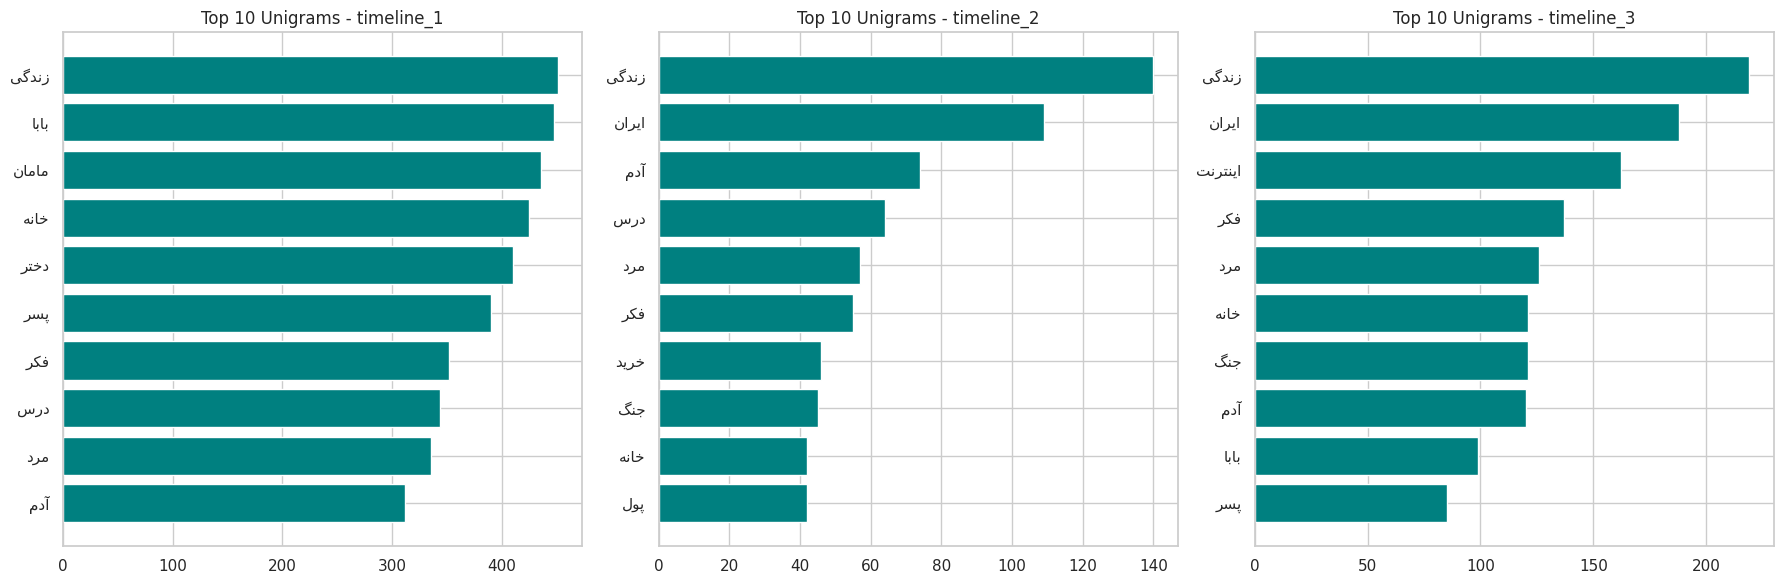

In [46]:
# Plot most frequent words per timeline
fig, axes = plt.subplots(1, 3, figsize = (18, 6))

for idx, tl in enumerate(sorted(df['timeline'].unique())):
    tdf = df[df['timeline'] == tl]
    all_tokens = [tok for tokens in tdf['final_tokens_freq'] for tok in tokens]
    cnt = Counter(all_tokens)
    top_itmes = cnt.most_common(10)
    words, freqs = zip(*top_itmes) if top_itmes else ([], [])

    # Reshape
    reshaped_words = [reshape_persian(w) for w in words]

    ax = axes[idx]
    ax.barh(reshaped_words, freqs, color = 'teal')
    ax.set_title(f'Top 10 Unigrams - {tl}')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [47]:
# Sample for top sentences 
MAX_SAMPLES_PER_WORD = 50
word_samples = {word: [] for word in all_top_words}

for idx, row in df.iterrows():
    text = row['normalized']
    if not isinstance(text, str) or text.strip() == '':
        continue
    tokens = text.split()
    for word in all_top_words:
        if word in tokens and len(word_samples[word]) < MAX_SAMPLES_PER_WORD:
            word_samples[word].append(text)
    if all(len(v) >= MAX_SAMPLES_PER_WORD for v in word_samples.values()):
        break

for word in all_top_words:
    print(f'{word}: {len(word_samples[word])} samples.')

سر: 50 samples.
حرف: 50 samples.
دانشجو: 27 samples.
دختر: 50 samples.
کیر: 38 samples.
پسر: 50 samples.
استفاده: 50 samples.
گران: 4 samples.
اینترنت: 50 samples.
تومان: 50 samples.
مرد: 50 samples.
ازدواج: 50 samples.
کانفیگ: 50 samples.
زن: 50 samples.
آدم: 50 samples.
دانشگاه: 50 samples.
ترامپ: 50 samples.
صدا: 46 samples.
داشت: 50 samples.
زد: 50 samples.
نسل: 50 samples.
چپ: 21 samples.
فکر: 50 samples.
ماه: 50 samples.
جلو: 50 samples.
تجربه: 50 samples.
کشور: 50 samples.
ماشین: 50 samples.
صبح: 50 samples.
دقیقه: 50 samples.
آموز: 0 samples.
جواب: 50 samples.
بابا: 50 samples.
زمان: 50 samples.
هزینه: 50 samples.
رابطه: 50 samples.
زبان: 50 samples.
خانه: 19 samples.
تهران: 50 samples.
بزرگ: 50 samples.
گریه: 50 samples.
هوش: 50 samples.
وضعی: 2 samples.
هفته: 50 samples.
دلم: 50 samples.
مادر: 50 samples.
یاد: 50 samples.
روان: 42 samples.
رایگان: 50 samples.
راه: 50 samples.
وصل: 50 samples.
تلگرام: 50 samples.
دوست: 50 samples.
انسان: 50 samples.
زنده: 50 samples.
اقتصاد: 2

In [ ]:
# POS and NER on samples
post_tagger = POSTagger()
ner_model = NER()